In [1]:
import pandas as pd 

df = pd.read_csv('data_center_hybrid.csv')
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


<h2 class="ml-heading-cyber">Basic Inspection</h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [2]:
df.columns

Index(['Year', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City',
       'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Daily_Water_Usage_Gallons', 'Surrounding_Water_Stress_Tier'],
      dtype='str')



We use `df.columns` to list all column names in the DataFrame.

This helps us confirm the structure of the dataset and identify which features are available for analysis and classification.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  str    
 2   Facility_Name                  126770 non-null  str    
 3   Owner_Company                  126770 non-null  str    
 4   City                           126770 non-null  str    
 5   Country                        126770 non-null  str    
 6   Facility_Type                  126770 non-null  str    
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  str    
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons      126770 non

<h2 class="ml-heading-cyber"> Exploratory Data Analysis </h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [4]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


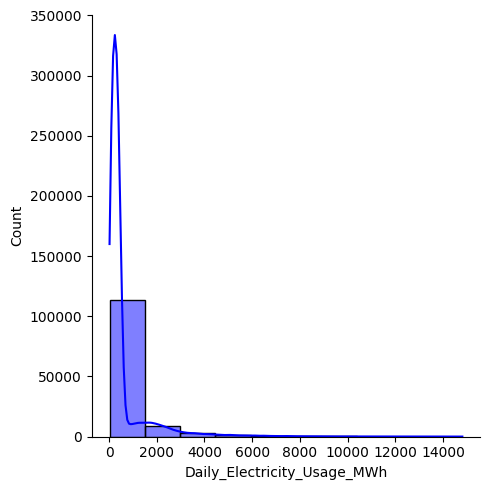

In [5]:
import seaborn as sns

sns.displot(data = df , x = 'Daily_Electricity_Usage_MWh', bins = 10 , kde = True , color = 'blue' )

**Key takeaway:** Daily electricity usage is **strongly right-skewed**. Most facilities fall in the lower-to-mid usage range, while a smaller group of very large sites creates a long tail. This matches the `describe()` results (median ≈ 303 MWh vs mean ≈ 605 MWh) and supports later outlier handling.

<Axes: xlabel='Daily_Electricity_Usage_MWh', ylabel='Daily_Water_Usage_Gallons'>

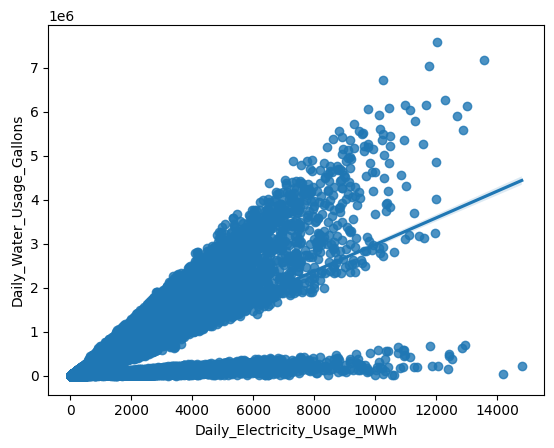

In [6]:
sns.regplot(x = 'Daily_Electricity_Usage_MWh', y = 'Daily_Water_Usage_Gallons', data = df)

**Key takeaway:** There is a **clear positive relationship** between daily electricity and daily water use. Facilities that draw more power generally consume more water, which makes sense because larger or more intensive operations often need both more compute power and more cooling water.

<Axes: xlabel='Estimated_Capacity_MW', ylabel='Daily_Electricity_Usage_MWh'>

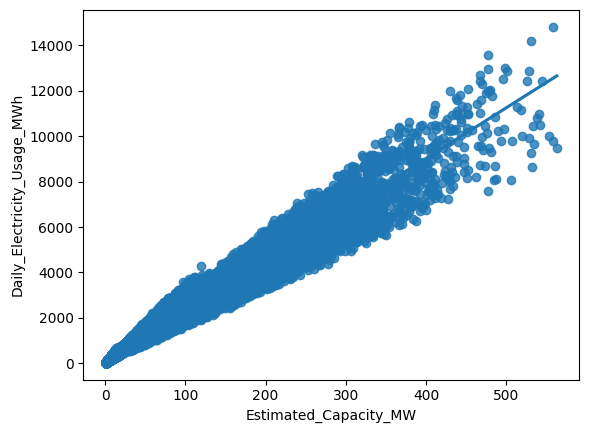

In [7]:
sns.regplot( x = 'Estimated_Capacity_MW' , y = 'Daily_Electricity_Usage_MWh' , data = df)

**Key takeaway:** **Estimated capacity and electricity use move together** — larger data centers (higher MW) tend to report higher daily electricity consumption. Capacity is one of the strongest practical drivers of energy demand in this dataset.


<Axes: xlabel='PUE', ylabel='Daily_Electricity_Usage_MWh'>

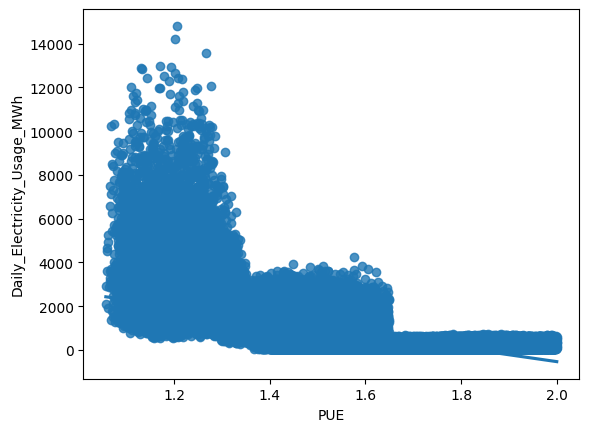

In [8]:
sns.regplot( x = 'PUE' , y = 'Daily_Electricity_Usage_MWh' , data = df)

**Key takeaway:** The link between **PUE and total electricity use is weak** compared with capacity. PUE reflects efficiency, but total consumption is driven mainly by facility size and workload, so PUE alone does not explain most of the variation in electricity usage.


<Axes: xlabel='Cooling_System_Type', ylabel='Daily_Water_Usage_Gallons'>

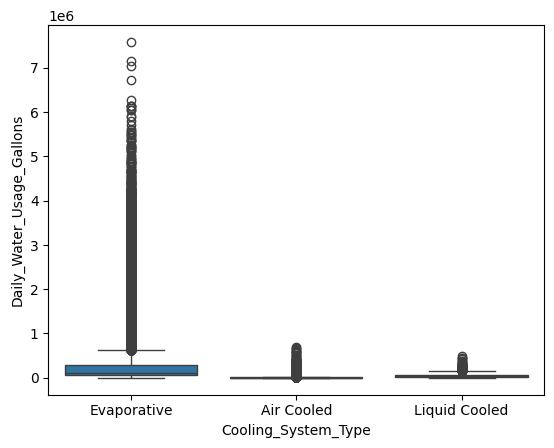

In [9]:
sns.boxplot( x = 'Cooling_System_Type' , y = 'Daily_Water_Usage_Gallons' , data = df)

**Key takeaway:** **Cooling system type strongly affects water use.** Water-heavy cooling methods (such as evaporative systems) show higher typical water consumption and wider spread than less water-dependent options. Cooling type is likely an important feature for predicting surrounding water stress.

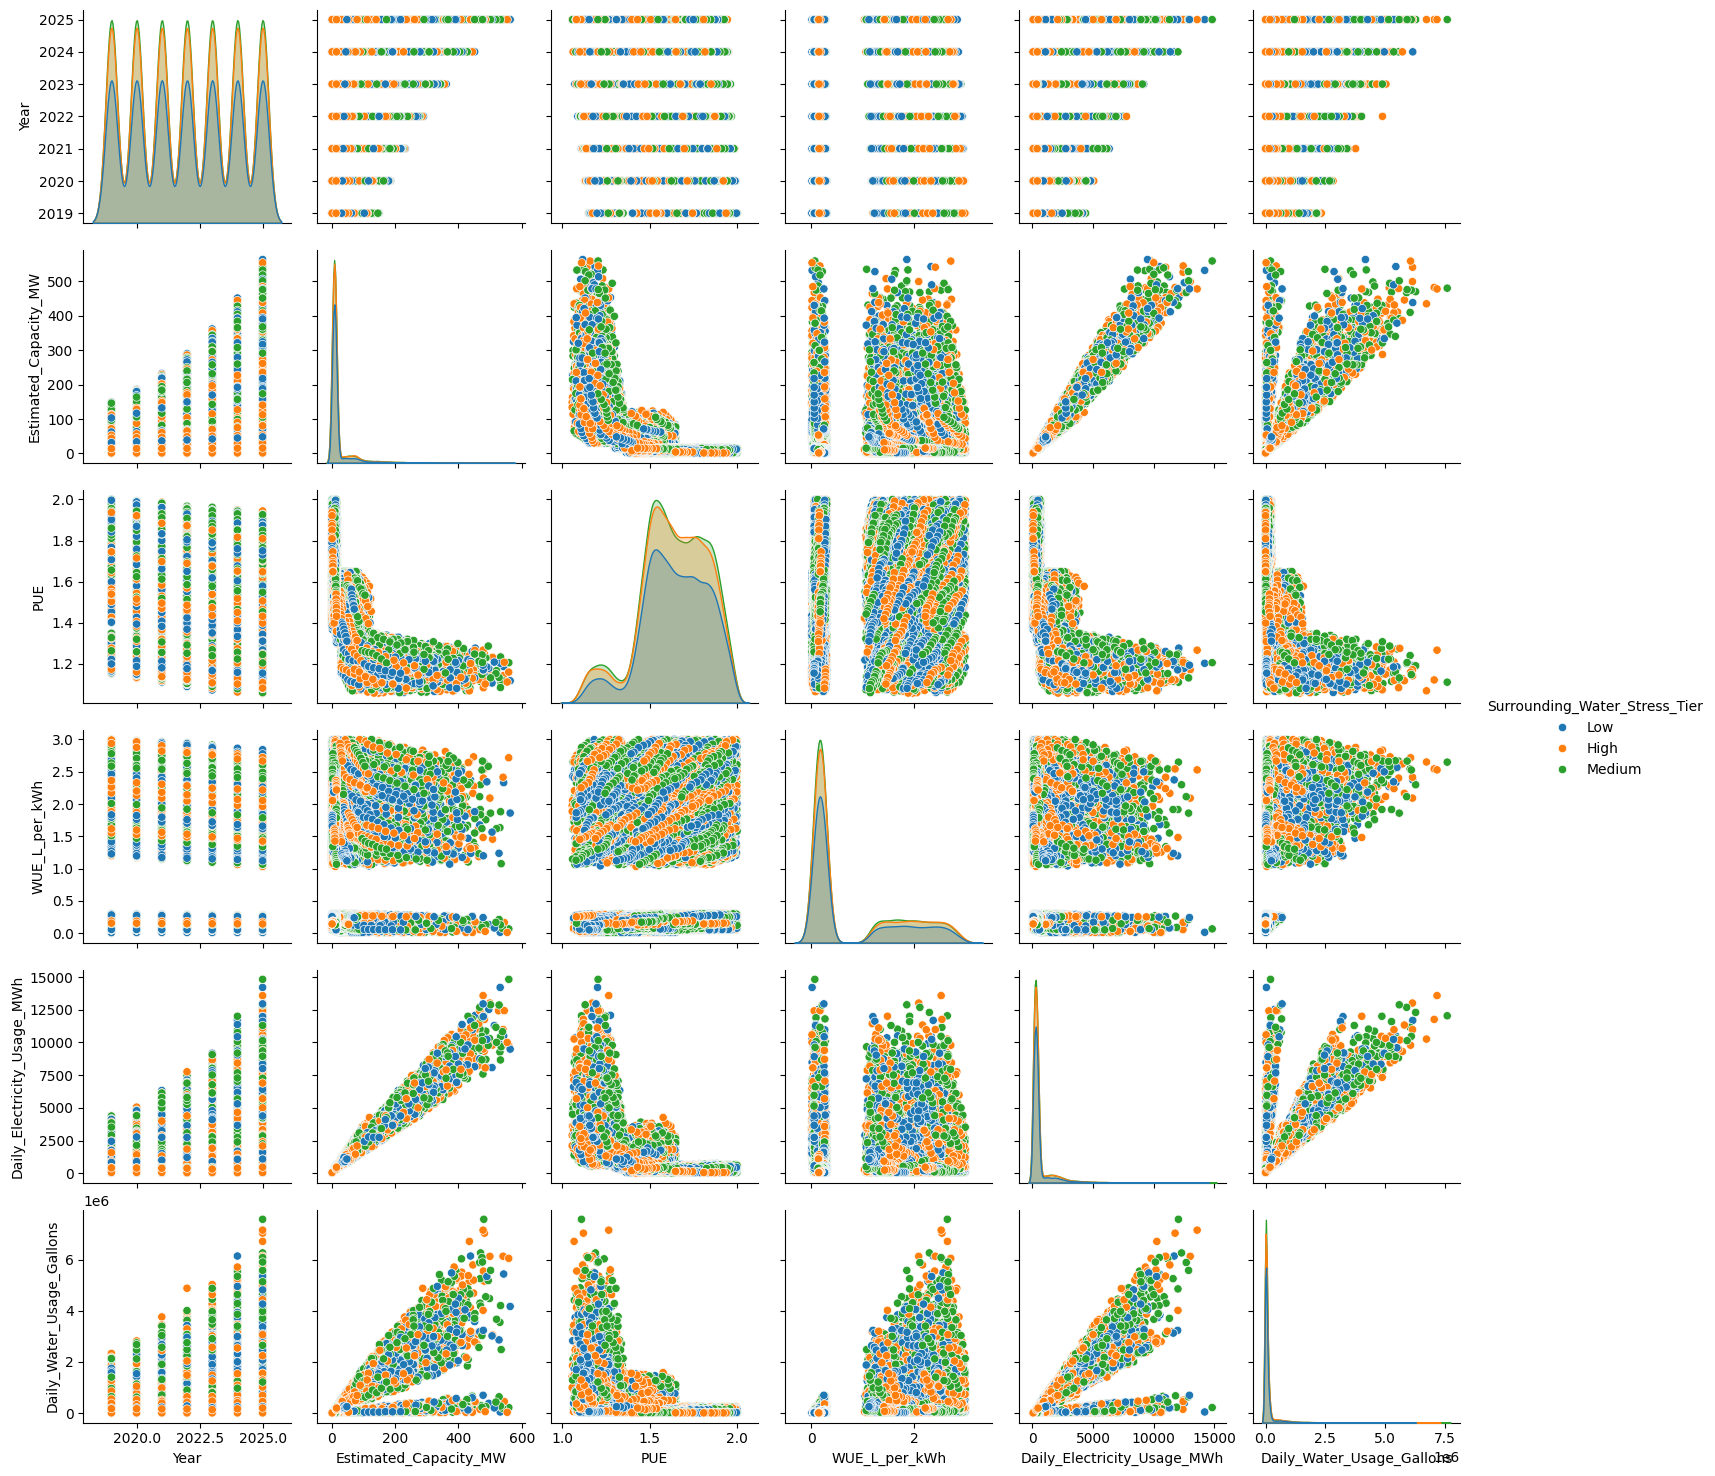

In [10]:
sns.pairplot(  df , hue = 'Surrounding_Water_Stress_Tier')

<h2 class="ml-heading-cyber"> Detect the outliers using Boxplot </h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [11]:
num_cols = df.select_dtypes(include = [ 'int64' , 'float64'] ).columns
print(num_cols)

Index(['Year', 'Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh',
       'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons'],
      dtype='str')


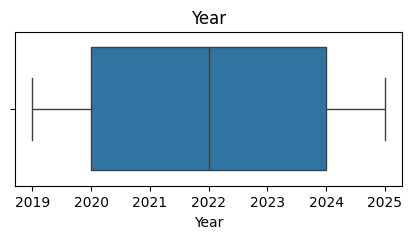

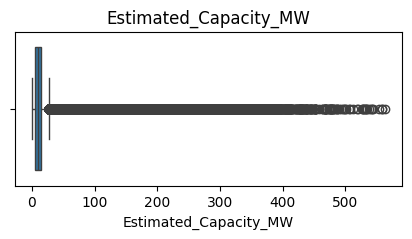

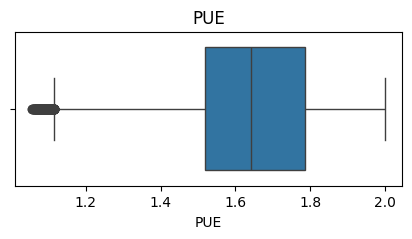

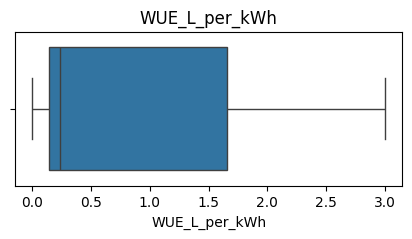

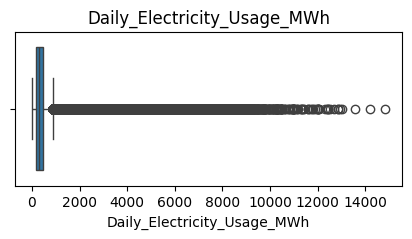

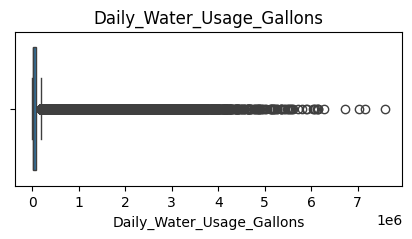

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<h2 class="ml-heading-cyber">Remove the outliers by using IQR method </h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [13]:
Q1 = df["Daily_Electricity_Usage_MWh"].quantile(0.25)
Q3 = df["Daily_Electricity_Usage_MWh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Daily_Electricity_Usage_MWh"] < lower) |
    (df["Daily_Electricity_Usage_MWh"] > upper)
]

print(outliers.shape)

(18103, 14)


In [14]:
df["Daily_Electricity_Usage_MWh"] = df[
    "Daily_Electricity_Usage_MWh"
].clip(lower, upper)

In [15]:
Q1 = df["Daily_Water_Usage_Gallons"].quantile(0.25)
Q3 = df["Daily_Water_Usage_Gallons"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Daily_Water_Usage_Gallons"] < lower) |
    (df["Daily_Water_Usage_Gallons"] > upper)
]

print(outliers.shape)

(14259, 14)


In [16]:
df["Daily_Water_Usage_Gallons"] = df["Daily_Water_Usage_Gallons"].clip(lower , upper)

In [17]:
Q1 = df["PUE"].quantile(0.25)
Q3 = df["PUE"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["PUE"] < lower) |
    (df["PUE"] > upper)
]

print(outliers.shape)

(561, 14)


In [18]:
df["PUE"] = df["PUE"].clip(lower , upper)

In [19]:
Q1 = df["WUE_L_per_kWh"].quantile(0.25)
Q3 = df["WUE_L_per_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["WUE_L_per_kWh"] < lower) |
    (df["WUE_L_per_kWh"] > upper)
]

print(outliers.shape)

(0, 14)


In [20]:
df["WUE_L_per_kWh"] = df["WUE_L_per_kWh"].clip(lower , upper)

In [21]:
Q1 = df["Estimated_Capacity_MW"].quantile(0.25)
Q3 = df["Estimated_Capacity_MW"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Estimated_Capacity_MW"] < lower) |
    (df["Estimated_Capacity_MW"] > upper)
]

print(outliers.shape)

(19076, 14)


In [22]:
df["Estimated_Capacity_MW"] = df["Estimated_Capacity_MW"].clip(lower , upper)

<h2 class="ml-heading-cyber">Build the complete Pipeline using Random Forest Classifier</h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [23]:
X = df.drop("Surrounding_Water_Stress_Tier", axis=1)
y = df["Surrounding_Water_Stress_Tier"]

In [24]:
X = X.drop(
    ["Facility_ID", "Facility_Name"],
    axis=1
)

In [25]:
num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = X.select_dtypes(
    include="object"
).columns

print(num_cols)
print(cat_cols)

Index(['Year', 'Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh',
       'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons'],
      dtype='str')
Index(['Owner_Company', 'City', 'Country', 'Facility_Type',
       'Cooling_System_Type'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_18920\3389374399.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            MinMaxScaler(),
            num_cols
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


pipe = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [29]:
pipe.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

<h2 class="ml-heading-cyber"> Evaluation Metrics </h2>

<style>
  @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@500&display=swap');

  .ml-heading-cyber {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.4rem;          /* Toned down from 2rem */
    color: #f0f6fc;
    border-left: 3px solid #38bdf8; /* Slightly thinner accent line */
    padding-left: 10px;
    margin: 15px 0;
  }
</style>

In [30]:
from sklearn.metrics import classification_report , confusion_matrix

y_pred = pipe.predict(X_test)

print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test , y_pred))

[[8565  140  311]
 [ 256 6499  228]
 [ 301  145 8909]]
              precision    recall  f1-score   support

        High       0.94      0.95      0.94      9016
         Low       0.96      0.93      0.94      6983
      Medium       0.94      0.95      0.95      9355

    accuracy                           0.95     25354
   macro avg       0.95      0.94      0.95     25354
weighted avg       0.95      0.95      0.95     25354




This project focuses on predicting the **Surrounding Water Stress Tier** of data centers using machine learning techniques. The dataset was first explored through Exploratory Data Analysis (EDA) to understand its structure, identify missing values, and analyze feature distributions.

Data preprocessing was performed by handling missing values, encoding categorical features, and removing outliers from numerical features using the Interquartile Range (IQR) method. A machine learning pipeline was then built to automate preprocessing and model training while preventing data leakage.

The dataset was split into training and testing sets, and the model was trained and evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and the confusion matrix. Additionally, 5-fold cross-validation was performed to assess the model's stability and generalization performance.

The final model achieved an accuracy of approximately **95%**, with consistently high precision, recall, and F1-scores across all classes, demonstrating strong predictive performance. The results indicate that the developed classification model is reliable and effective for predicting the surrounding water stress tier of data centers based on their operational and environmental characteristics.